In [1]:
print('hello')

hello


In [2]:
import pandas as pd

weight will be the independant features
and the height will be the dependent features

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


#Read the data set

In [4]:
data = pd.read_csv('weight-height.csv')
data.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


Text(0.5, 1.0, 'Weight vs Height')

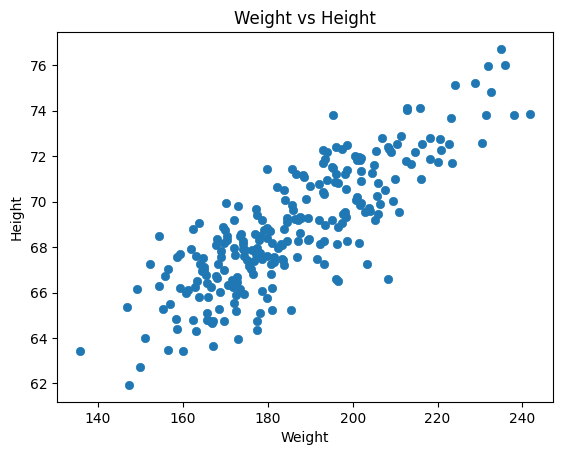

In [5]:
plt.scatter(data['Weight'], data['Height'], linewidths=0.5)
plt.xlabel('Weight')
# plt.xlim(0, 3)
plt.ylabel('Height')
plt.title('Weight vs Height')

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
## divide the data into independent and dependant features
X = data[['Weight']] # independent feature
y = data[['Height']] # dependent feature

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((199, 1), (50, 1), (199, 1), (50, 1))

In [10]:
X_train.head()

,Weight
132,185.662741
156,179.907717
213,206.032978
119,223.299335
139,183.044660


In [11]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [12]:
X_train = scaler.fit_transform(X_train) # fit = calculate mean and std, transform = apply the formula Z = (X - mean)/std
X_test = scaler.transform(X_test) # only transform because we have already calculated the mean and std it will use the same mean and std and apply the formula

# Reason I am doing it - My model shoudl Not know anything about the test data, it just have the information of the test data.

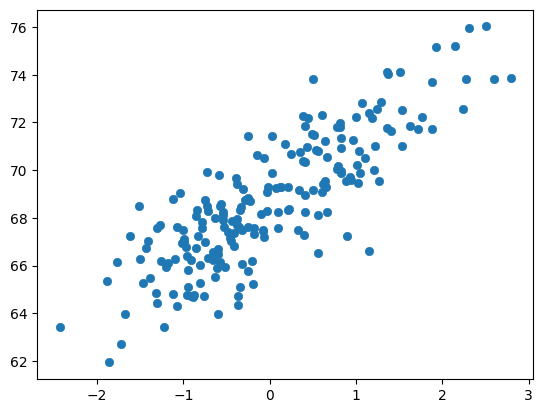

In [13]:
plt.scatter(X_train, y_train, linewidths=0.5)

In [14]:
# Train the linear Regression Model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [15]:
regressor.fit(X_train, y_train)

LinearRegression()

In [16]:
print('The slope or coeffiecent of weight is', regressor.coef_)
print('Intercept is', regressor.intercept_)

The slope or coeffiecent of weight is [[2.27319297]]
Intercept is [68.69669562]


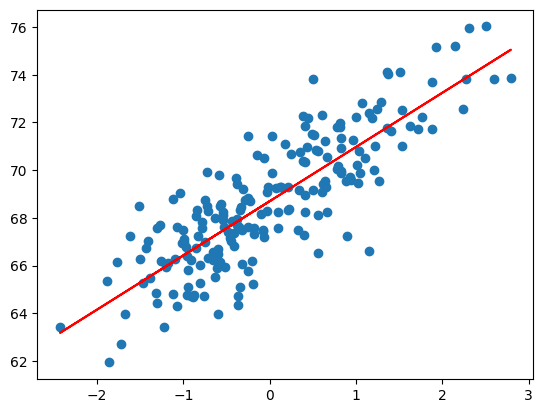

In [17]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train), color='red')
#best fit line

### prediction of train data
1. predicted height output = intercept + coef_(Weights)
2. y_pred_train = 68.6966 + 2.2731 * 

### prediction of test data
1. predicted height output = intercept + coef_ (Weights)
2. y_pred_test = 68.6966 + 2.2731 *

In [20]:
y_pred_test = regressor.predict(X_test)
y_pred_test, y_test

(array([[68.1195843 ],
        [68.57196852],
        [68.20951675],
        [70.22913474],
        [70.91819717],
        [68.25110353],
        [68.22023087],
        [69.93736984],
        [65.49624587],
        [68.57319402],
        [69.05727463],
        [74.01405114],
        [71.99935898],
        [68.91772005],
        [72.6780571 ],
        [67.53557888],
        [72.40301793],
        [67.26015314],
        [70.20923628],
        [66.12271232],
        [67.30702967],
        [68.40423516],
        [66.34704079],
        [68.50322861],
        [66.79391567],
        [69.12999365],
        [66.26828249],
        [68.87107343],
        [68.97184453],
        [66.68382568],
        [69.9276582 ],
        [70.94686807],
        [66.96629146],
        [68.74402127],
        [69.51229666],
        [70.5339527 ],
        [68.80169277],
        [71.31459829],
        [70.41656354],
        [67.79615704],
        [67.92870264],
        [69.59611493],
        [67.23744378],
        [70

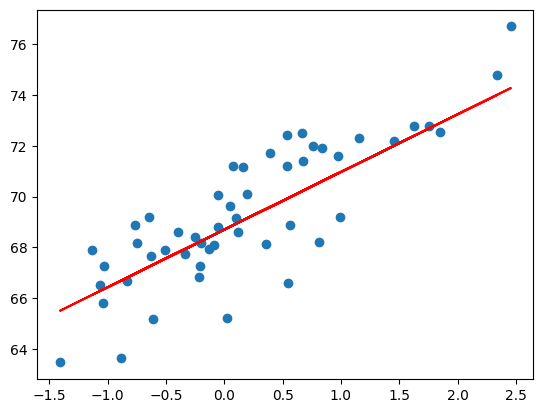

In [21]:
plt.scatter(X_test, y_test)
plt.plot(X_test,regressor.predict(X_test), color='red')

In [ ]:
## Performance Matrix
# Mean Squared Error, Mean Absolute Error, Root Mean Squared Error,
## adjusted R2, R2

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
print('Mean Squared Error is', mse)
print('Mean Absolute Error is', mae)
print('Root Mean Squared Error is', rmse)

Mean Squared Error is 2.3170732564053846
Mean Absolute Error is 1.2244060194976651
Root Mean Squared Error is 1.5221935673249263


In [23]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_test)
print('R2 Score is', score)

R2 Score is 0.6846316486930817


In [24]:
adjuted_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print('Adjusted R2 Score is', adjuted_r2)

Adjusted R2 Score is 0.6780614747075209


In [32]:
## Predict the height of a person with weight 80kg = 176.37 pound
scaled_weight = scaler.transform([[186]])
scaled_weight

C:\Users\jitesh.p\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.04697778]])

In [ ]:
print(regressor.predict([scaled_weight[0]])) # 2.54 cm = 1 inch

[[68.80348519]]


# Assumptions
how we can say that our model is performin well.
1--plot the scatter plot for the preditcion -- if it is linear distributed that we can consider that the model is performing well.
2--Residuals - difference between y_test - y_pred_test,
if we plot the residual using histplot ,if we are getting the normal distribution(gaussain distrubution where left and right are equally distributed if we consider the mean of the graph.) then we can consider that the model is performing well. 
3-- Scatter plot with respect to prediction and residual
   (Uniform distribution - data points will be availabel in both positive and negative points)


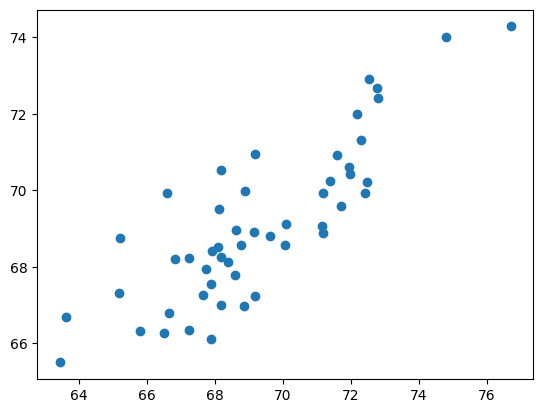

In [35]:
plt.scatter(y_test, y_pred_test)

In [36]:
residuals = y_test - y_pred_test


<Axes: ylabel='Count'>

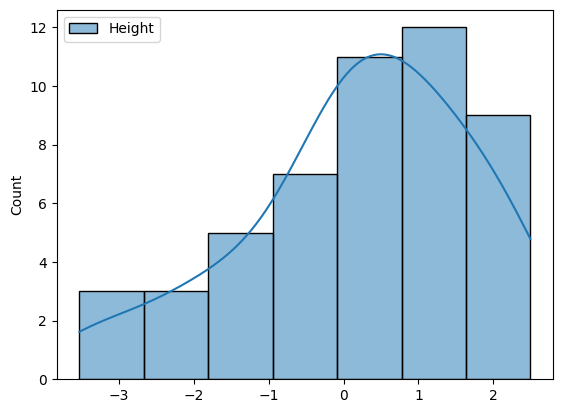

In [38]:
import seaborn as sns
sns.histplot(residuals,kde=True)

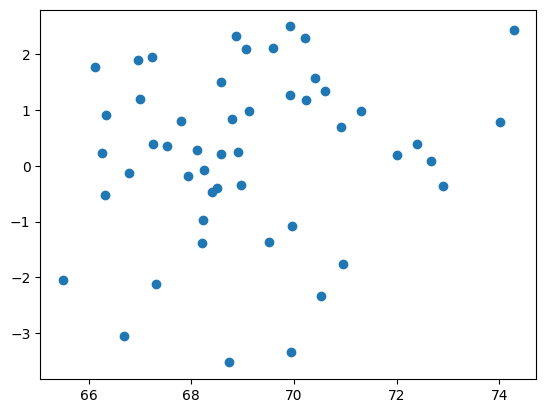

In [39]:
plt.scatter(y_pred_test, residuals)